<a href="https://colab.research.google.com/github/kristinacparadise-2013/US_Suicide_Trends_Analysis/blob/main/US_suicide_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import pandas as pd

#read data
df = pd.read_csv("Suicide_deaths_2018_2024.csv")
df.head()


,Notes,Year,Year Code,State,State Code,Sex,Sex Code,Deaths,Population,Crude Rate,Crude Rate Lower 95% Confidence Interval,Crude Rate Upper 95% Confidence Interval
0,NaN,2018.0,2018.0,Alabama,1.0,Female,F,181.0,2523756.0,7.2,6.1,8.2
1,NaN,2018.0,2018.0,Alabama,1.0,Male,M,642.0,2364115.0,27.2,25.1,29.3
2,NaN,2018.0,2018.0,Alaska,2.0,Female,F,40.0,352865.0,11.3,8.1,15.4
3,NaN,2018.0,2018.0,Alaska,2.0,Male,M,144.0,384573.0,37.4,31.3,43.6
4,NaN,2018.0,2018.0,Arizona,4.0,Female,F,289.0,3606307.0,8.0,7.1,8.9


In [9]:
df.columns = df.columns.str.lower().str.replace(" ", "_")

# Let's inspect missing values before dropping any rows
print("Missing values before dropna():")
print(df.isnull().sum())

# Temporarily commenting out df.dropna() to prevent losing all data
# df = df.dropna()

df.head()

Missing values before dropna():
notes                                       711
year                                         66
year_code                                    66
state                                        66
state_code                                   66
sex                                          66
sex_code                                     66
deaths                                       66
population                                   66
crude_rate                                   66
crude_rate_lower_95%_confidence_interval     66
crude_rate_upper_95%_confidence_interval     66
dtype: int64


,notes,year,year_code,state,state_code,sex,sex_code,deaths,population,crude_rate,crude_rate_lower_95%_confidence_interval,crude_rate_upper_95%_confidence_interval
0,NaN,2018.0,2018.0,Alabama,1.0,Female,F,181.0,2523756.0,7.2,6.1,8.2
1,NaN,2018.0,2018.0,Alabama,1.0,Male,M,642.0,2364115.0,27.2,25.1,29.3
2,NaN,2018.0,2018.0,Alaska,2.0,Female,F,40.0,352865.0,11.3,8.1,15.4
3,NaN,2018.0,2018.0,Alaska,2.0,Male,M,144.0,384573.0,37.4,31.3,43.6
4,NaN,2018.0,2018.0,Arizona,4.0,Female,F,289.0,3606307.0,8.0,7.1,8.9


In [10]:
# Drop the 'notes' column due to a high number of missing values
df = df.drop(columns=['notes'])

print("DataFrame after dropping 'notes' column:")
display(df.head())

DataFrame after dropping 'notes' column:


,year,year_code,state,state_code,sex,sex_code,deaths,population,crude_rate,crude_rate_lower_95%_confidence_interval,crude_rate_upper_95%_confidence_interval
0,2018.0,2018.0,Alabama,1.0,Female,F,181.0,2523756.0,7.2,6.1,8.2
1,2018.0,2018.0,Alabama,1.0,Male,M,642.0,2364115.0,27.2,25.1,29.3
2,2018.0,2018.0,Alaska,2.0,Female,F,40.0,352865.0,11.3,8.1,15.4
3,2018.0,2018.0,Alaska,2.0,Male,M,144.0,384573.0,37.4,31.3,43.6
4,2018.0,2018.0,Arizona,4.0,Female,F,289.0,3606307.0,8.0,7.1,8.9


In [11]:
# Drop rows with any remaining missing values
df = df.dropna()

print("Missing values after dropping rows with NaN:")
print(df.isnull().sum())

print("DataFrame after dropping rows with NaN:")
display(df.head())

Missing values after dropping rows with NaN:
year                                        0
year_code                                   0
state                                       0
state_code                                  0
sex                                         0
sex_code                                    0
deaths                                      0
population                                  0
crude_rate                                  0
crude_rate_lower_95%_confidence_interval    0
crude_rate_upper_95%_confidence_interval    0
dtype: int64
DataFrame after dropping rows with NaN:


,year,year_code,state,state_code,sex,sex_code,deaths,population,crude_rate,crude_rate_lower_95%_confidence_interval,crude_rate_upper_95%_confidence_interval
0,2018.0,2018.0,Alabama,1.0,Female,F,181.0,2523756.0,7.2,6.1,8.2
1,2018.0,2018.0,Alabama,1.0,Male,M,642.0,2364115.0,27.2,25.1,29.3
2,2018.0,2018.0,Alaska,2.0,Female,F,40.0,352865.0,11.3,8.1,15.4
3,2018.0,2018.0,Alaska,2.0,Male,M,144.0,384573.0,37.4,31.3,43.6
4,2018.0,2018.0,Arizona,4.0,Female,F,289.0,3606307.0,8.0,7.1,8.9


In [13]:
#Check info in dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 711 entries, 0 to 710
Data columns (total 11 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   year                                      711 non-null    float64
 1   year_code                                 711 non-null    float64
 2   state                                     711 non-null    object 
 3   state_code                                711 non-null    float64
 4   sex                                       711 non-null    object 
 5   sex_code                                  711 non-null    object 
 6   deaths                                    711 non-null    float64
 7   population                                711 non-null    float64
 8   crude_rate                                711 non-null    float64
 9   crude_rate_lower_95%_confidence_interval  711 non-null    float64
 10  crude_rate_upper_95%_confidence_interval  7

In [18]:
df["deaths"] = pd.to_numeric(df["deaths"])
df["population"] = pd.to_numeric(df["population"])
df["crude_rate"] = pd.to_numeric(df["crude_rate"])

df.groupby("year")["deaths"].sum()

,deaths
year,
2018.0,48344.0
2019.0,47511.0
2020.0,45979.0
2021.0,48176.0
2022.0,49468.0
2023.0,49316.0
2024.0,48816.0


In [19]:
df.groupby("year")["crude_rate"].mean()

,crude_rate
year,
2018.0,16.831373
2019.0,16.710784
2020.0,16.320588
2021.0,17.265347
2022.0,17.240594
2023.0,16.790196
2024.0,16.674257


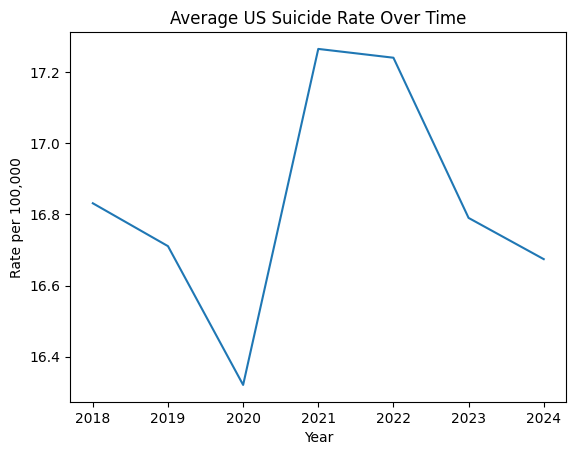

In [20]:
import matplotlib.pyplot as plt

trend = df.groupby("year")["crude_rate"].mean()

plt.plot(trend.index, trend.values)
plt.title("Average US Suicide Rate Over Time")
plt.xlabel("Year")
plt.ylabel("Rate per 100,000")
plt.show()

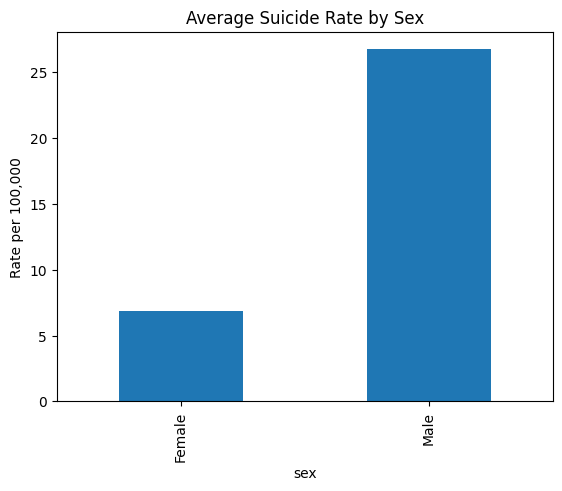

In [21]:
sex_rate = df.groupby("sex")["crude_rate"].mean()

sex_rate.plot(kind="bar")
plt.title("Average Suicide Rate by Sex")
plt.ylabel("Rate per 100,000")
plt.show()

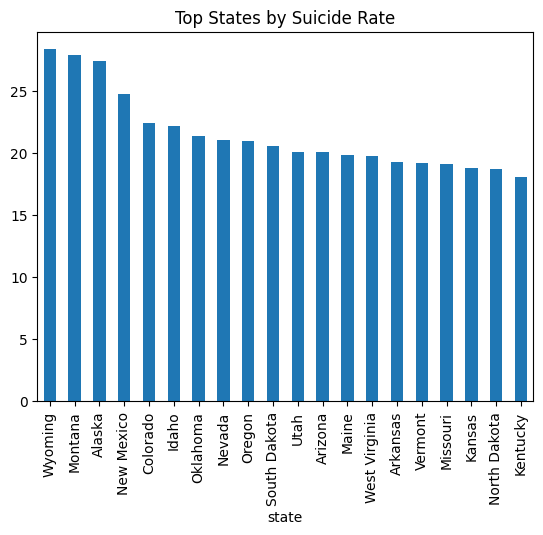

In [24]:
state_rate = df.groupby("state")["crude_rate"].mean().sort_values(ascending=False)

state_rate.head(20).plot(kind="bar")
plt.title("Top States by Suicide Rate")
plt.show()

In [26]:
state_variability = df.groupby("state")["crude_rate"].std().sort_values(ascending=False)

state_variability.head(20)

,crude_rate
state,
Wyoming,19.806465
Montana,16.986271
Alaska,16.334796
New Mexico,15.399472
Oklahoma,13.670609
Idaho,13.635903
West Virginia,13.006906
Maine,12.682193
Arkansas,12.672190


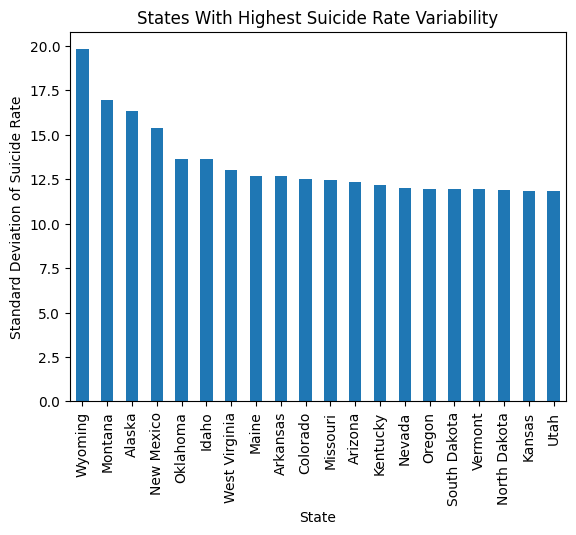

In [27]:
state_variability.head(20).plot(kind="bar")

plt.title("States With Highest Suicide Rate Variability")
plt.ylabel("Standard Deviation of Suicide Rate")
plt.xlabel("State")

plt.show()

In [28]:
df.to_csv("clean_suicide_data.csv", index=False)